# Practical plotting with seaborn and matplotlib

Seaborn is the first plotting tool in this course: it turns tidy pandas data
into useful statistical plots quickly. Matplotlib appears as the control layer
for figure size, labels, reference lines, annotations, subplots, layout, and
export.

Tutorial examples mostly use the `tips` and `flights` datasets. The exercise
statements mostly use `penguins`, so students transfer the same plotting ideas
to fresh data. All three source datasets are briefly inspected at the start.

## 0. Setup

Import the core libraries, set a readable default theme, and load the example
datasets used in the tutorial.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Load the source datasets and create a real datetime column for the flights
time-series examples.

In [2]:
tips = sns.load_dataset("tips")
flights = sns.load_dataset("flights")
penguins = sns.load_dataset("penguins")

Have a look at all three

In [3]:
print(tips.info())
tips.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


In [4]:
print(flights.info())
flights.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB
None


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132


In [5]:
print(penguins.info())
penguins.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB
None


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female


## 1. First seaborn plot: scatter plot

Most seaborn functions take `data=` plus column names such as `x=`, `y=`,
`hue=`, and `style=`. This keeps plotting code close to the question being
asked.

<Axes: xlabel='total_bill', ylabel='tip'>

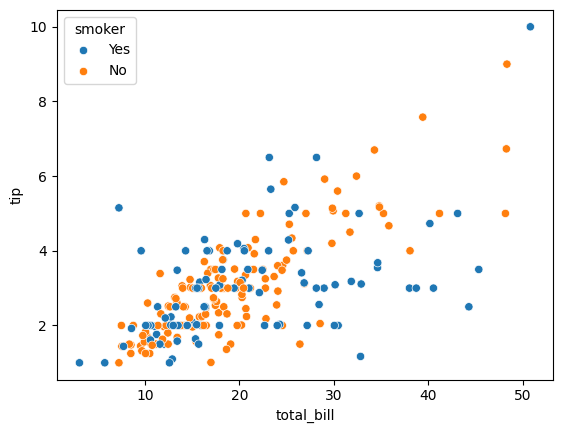

In [6]:
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="smoker",
)

Matplotlib can be used to change the properties of the graph:

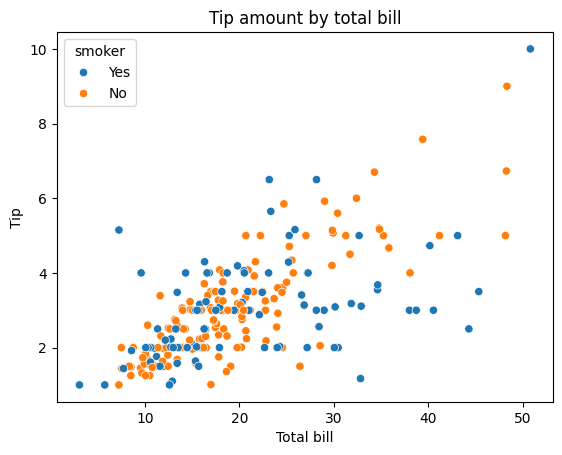

In [7]:
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="smoker",
)
plt.title("Tip amount by total bill")
plt.xlabel("Total bill")
plt.ylabel("Tip")
plt.show()

The same interface can map extra variables to visual properties. Here, marker
style separates lunch and dinner observations.

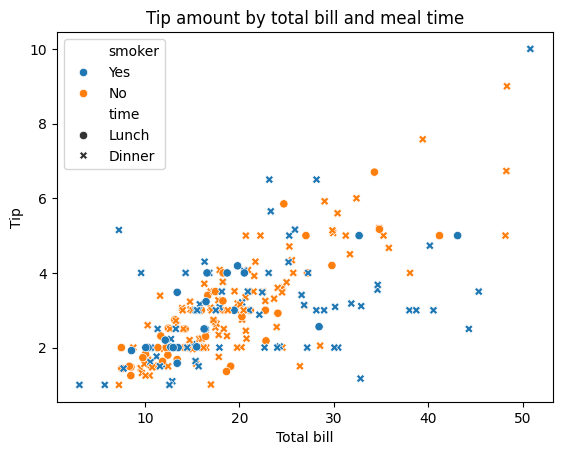

In [8]:
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="smoker",
    style="time",
)
plt.title("Tip amount by total bill and meal time")
plt.xlabel("Total bill")
plt.ylabel("Tip")
plt.show()

### Exercise 1: First seaborn plot

Use `penguins = sns.load_dataset("penguins")`.

1. Inspect `penguins` with `.head(3)` and `.info()`.
2. Drop rows with missing `sex`, `flipper_length_mm`, or `body_mass_g`.
3. Create a scatter plot of `flipper_length_mm` vs. `body_mass_g`.
4. Encode `species` with `hue` and `sex` with `style`.
5. Add the title `Penguin body mass by flipper length`.
6. Label the axes `Flipper length (mm)` and `Body mass (g)`.
7. BONUS: Set `alpha=0.75` to reduce overplotting.
8. BONUS: Create a second version without `style="sex"` and decide which
   version is easier to read.

## 2. Introducing the object-oriented Matplotlib API

So far, you have used the so called *stateful* Matplotlib API (using `plt`).

The object-oriented approach allows for more customization.

At the core of Matplotlib is the **Figure-Axes structure**:

- A **Figure** is the overall container for everything.
- Inside a Figure, you have one or more **Axes**, which are the actual plotting areas.
- The **Axes** contain everything from **lines, markers, text, grid lines, and labels**.

Let's start by recreating the previous plot.

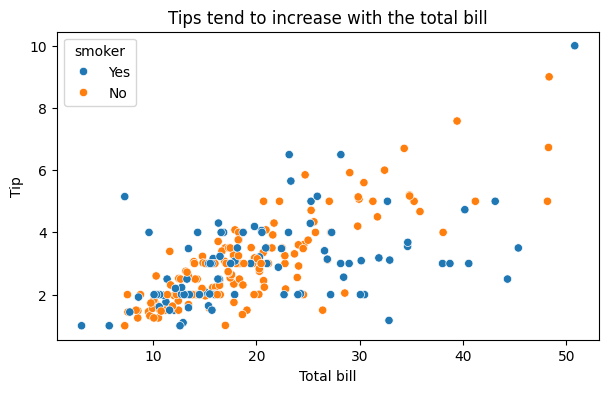

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="smoker",
    ax=ax,
)
ax.set(
    title="Tips tend to increase with the total bill",
    xlabel="Total bill",
    ylabel="Tip",
)
# we still need the stateful plt API to explicitly show the figure
# without plt.show(), jupyter will display the figure but also print its str representation
plt.show()

Using the `ax` object, we can add reference lines and annotations. `fig` allows us to change the overall layout and also save the figure as a file.

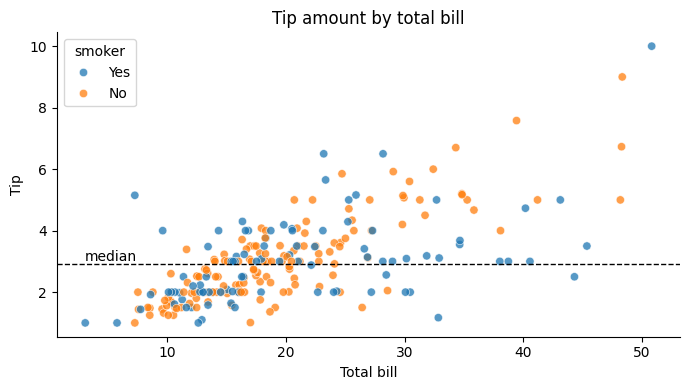

In [10]:
median_tip = tips["tip"].median()
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="smoker",
    alpha=0.75,
    ax=ax,
)
ax.axhline(median_tip, linestyle="--", color="black", linewidth=1)
ax.annotate(
    text="median",
    xy=(tips["total_bill"].min(), median_tip + 0.1),
)
ax.set(title="Tip amount by total bill", xlabel="Total bill", ylabel="Tip")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

### Exercise 2: Polish with matplotlib

Use `penguins`.

1. Create `fig, ax = plt.subplots(figsize=(7, 4))`.
2. Draw a seaborn scatter plot of `flipper_length_mm` vs. `body_mass_g`, with
   `hue="species"`, on that `ax`.
3. Add a dashed vertical reference line at the median of `flipper_length_mm`.
4. Annotate the median line with the median value rounded to one decimal place.
5. Add the title `Body mass by flipper length` and clear axis labels.
6. Remove the top and right spines and call `fig.tight_layout()`.
7. BONUS: Add a light grid with `alpha=0.3`.
8. BONUS: Save the figure as `penguin_flipper_body_mass.png` with `dpi=300`
   and `bbox_inches="tight"`.

## 3. Lineplots

Unless you aggregate the data before plotting, lineplots may show the mean and a confidence band if more than one row exists for a given unit in the x-Axis.

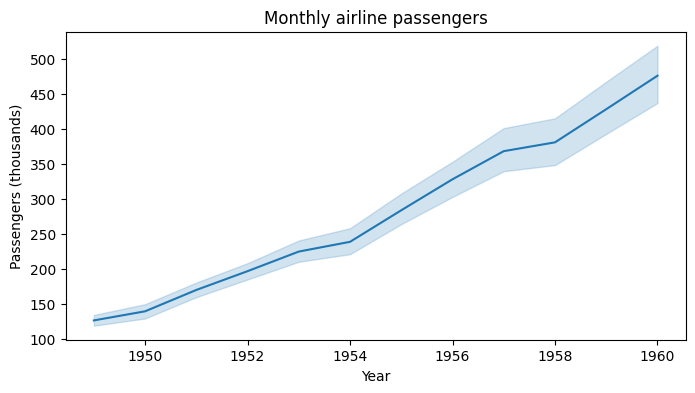

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=flights, x="year", y="passengers", ax=ax)
ax.set(
    title="Monthly airline passengers", xlabel="Year", ylabel="Passengers (thousands)"
)
plt.show()

By add a new column "period", we can increase the level of detail:

In [12]:
flights["period"] = pd.to_datetime(
    flights["year"].astype(str) + "-" + flights["month"].astype(str),
    format="%Y-%b",
)
print(flights.info())
flights.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   year        144 non-null    int64         
 1   month       144 non-null    category      
 2   passengers  144 non-null    int64         
 3   period      144 non-null    datetime64[us]
dtypes: category(1), datetime64[us](1), int64(2)
memory usage: 4.1 KB
None


,year,month,passengers,period
0,1949,Jan,112,1949-01-01
1,1949,Feb,118,1949-02-01
2,1949,Mar,132,1949-03-01


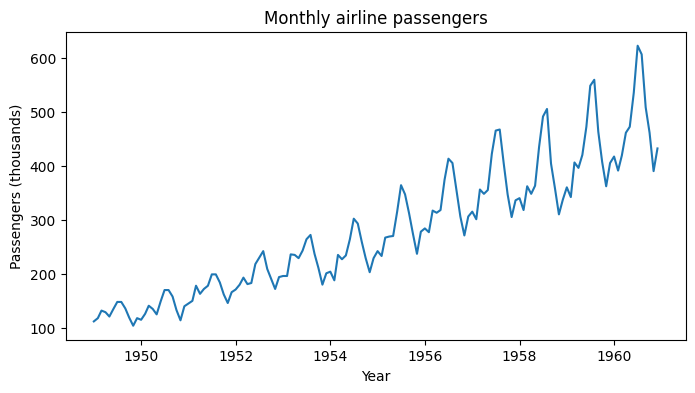

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=flights, x="period", y="passengers", ax=ax)
ax.set(
    title="Monthly airline passengers", xlabel="Year", ylabel="Passengers (thousands)"
)
plt.show()

## 4. Barplots

Bar plots also summarize groups directly. This example uses smoker status within
each day, where all displayed groups have observations.

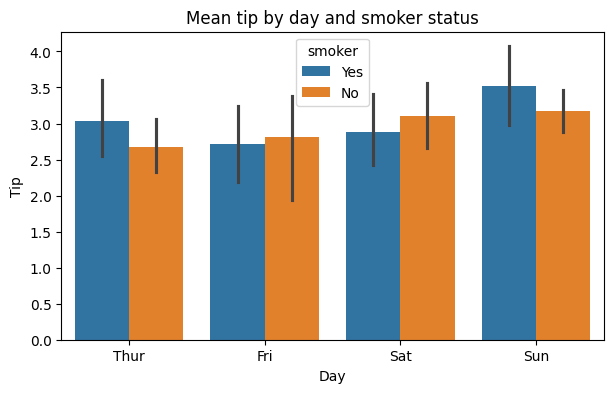

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=tips,
    x="day",
    y="tip",
    hue="smoker",
    errorbar=("ci", 95),
    ax=ax,
)
ax.set(title="Mean tip by day and smoker status", xlabel="Day", ylabel="Tip")
plt.show()

If you want to show the sums per group instead of means, you can pre-aggregate or ask for a different "estimator":

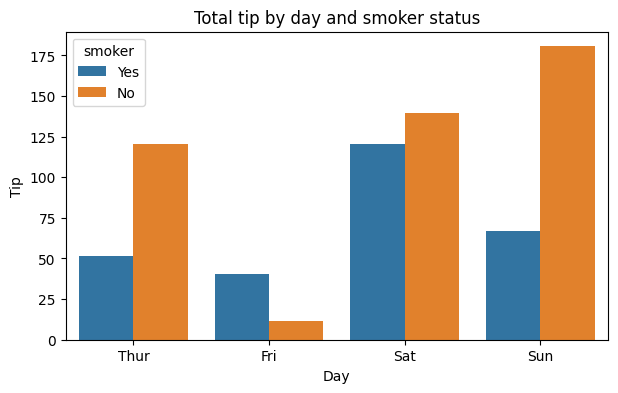

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=tips,
    x="day",
    y="tip",
    hue="smoker",
    estimator="sum",
    errorbar=None,
    ax=ax,
)
ax.set(title="Total tip by day and smoker status", xlabel="Day", ylabel="Tip")
plt.show()

<Axes: xlabel='day', ylabel='tip'>

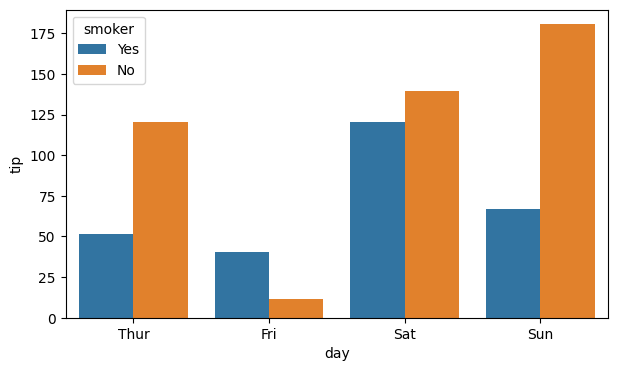

In [16]:
# alternatively, sum up before plotting
df_plot = tips.groupby(["day", "smoker"])["tip"].sum().reset_index()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=df_plot,
    x="day",
    y="tip",
    hue="smoker",
    ax=ax,
)

### Exercise 3: Trends and grouped means

1. From `flights`, create a line plot of `passengers` over `period`.
2. Add the title `Monthly airline passengers` and label the axes `Year` and
   `Passengers`.
3. Filter `flights` to March and September, remove unused month categories,
   and plot both trends with `hue="month"` and `marker="o"`.
4. Title the filtered plot `March and September passenger trends`.
5. From `penguins`, drop rows with missing `sex` or `body_mass_g`.
6. Create a bar plot of mean `body_mass_g` by `species`, split by `sex`, using
   `errorbar=("ci", 95)`.
7. Add the title `Mean body mass by species and sex` and clear axis labels.
8. BONUS: Move the bar-plot legend to the upper left and give it the title
   `Sex`.
9. BONUS: Remove the top and right spines from the bar plot.

## 5. Distributions and categorical comparisons

Histograms and KDEs show distributions. Box and violin plots compare
distributions across categories.

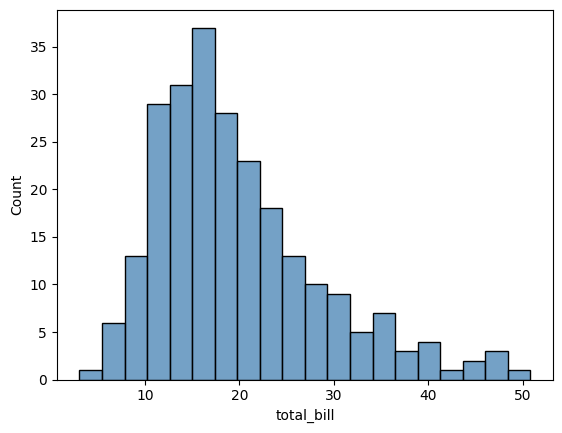

In [17]:
sns.histplot(data=tips, x="total_bill", bins=20, color="steelblue", edgecolor="black")
plt.show()

Adding `hue` splits the distribution, while density scaling makes group shapes
easier to compare.

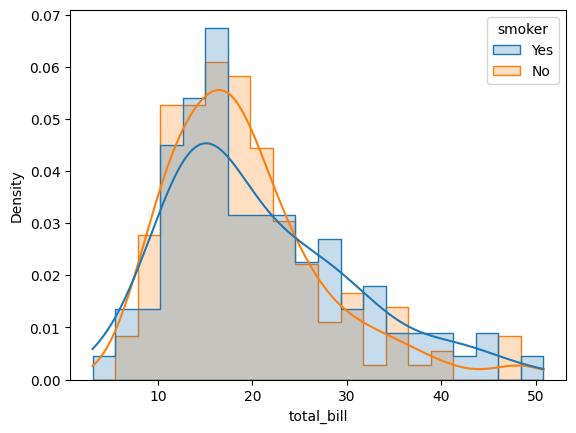

In [18]:
sns.histplot(
    data=tips,
    x="total_bill",
    hue="smoker",
    bins=20,
    stat="density",
    common_norm=False,
    kde=True,
    element="step",
)
plt.show()

A box plot gives a compact category-by-category view of medians and spread.

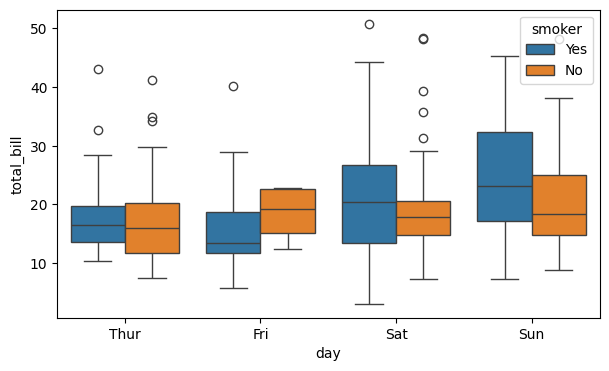

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=tips, x="day", y="total_bill", hue="smoker", ax=ax)
plt.show()

A violin plot shows the same categorical comparison with more detail about
distribution shape.

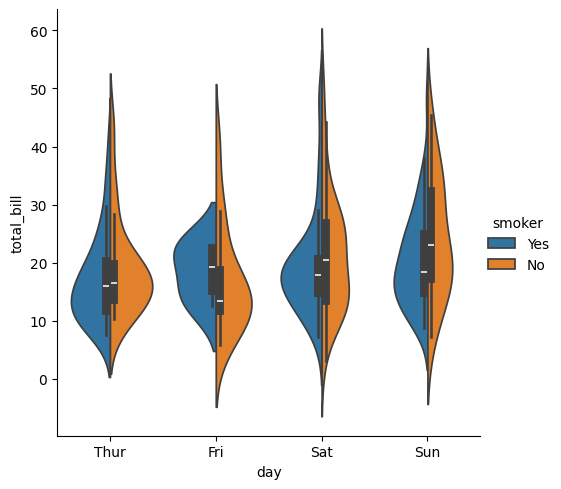

In [20]:
sns.catplot(data=tips, kind="violin", x="day", y="total_bill", hue="smoker", split=True)
plt.show()

### Exercise 4: Distributions and categories

Use `penguins`.

1. Create a combined histogram and density plot comparing `body_mass_g`
   distributions by `species`.
2. Use `bins=20`, `stat="density"`, `common_norm=False`, `element="step"`,
   and `kde=True`.
3. Add the title `Penguin body mass distributions by species` and label the
   axes `Body mass (g)` and `Density`.
4. Drop rows with missing `sex` or `body_mass_g`, then create box plots of
   `body_mass_g` by `species` and `sex`.
5. Add the title `Body mass spread by species and sex` and clear axis labels.
6. Create violin plots for the same species-and-sex comparison.
7. Add the title `Body mass distribution shape by species and sex` and compare
   the violin plot with the box plot.
8. BONUS: Use the same `species_order` for both the box plot and violin plot.
9. BONUS: State which plot better shows distribution shape and which plot is
   clearer for medians and outliers.

## 5. Heatmaps

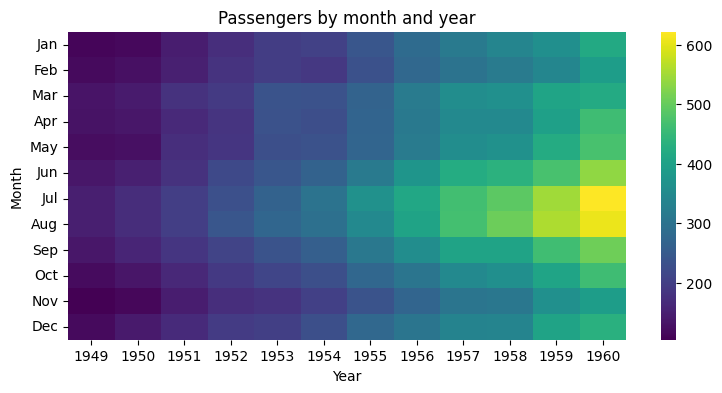

In [21]:
flight_matrix = flights.pivot_table(
    index="month",
    columns="year",
    values="passengers",
    observed=True,
)
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(flight_matrix, cmap="viridis", ax=ax)
ax.set(title="Passengers by month and year", xlabel="Year", ylabel="Month")
plt.show()

The same heatmap pattern works for correlations after selecting numeric
columns that belong to the same analytical question.

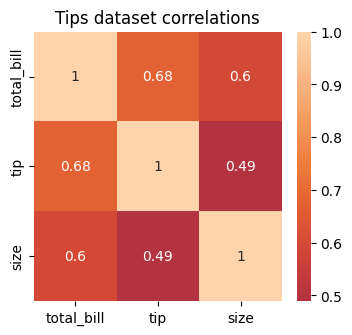

In [22]:
tips_numeric = ["total_bill", "tip", "size"]
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(tips[tips_numeric].corr(), annot=True, center=0, ax=ax)
ax.set(title="Tips dataset correlations")
plt.show()

### Exercise 5: Relationship summaries

Use `penguins`.

1. Select `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, and
   `body_mass_g`; exclude `year`.
2. Compute the correlation matrix and draw an annotated heatmap centered on
   zero.
3. Add the title `Penguins measurement correlations`.
9. BONUS: Use a diverging colormap and square cells in the heatmap.

## 6. Facets, manual subplots, and export

`FacetGrid` is concise for small multiples. Manual matplotlib subplots are
better when each panel needs custom lines, annotations, or axis control.

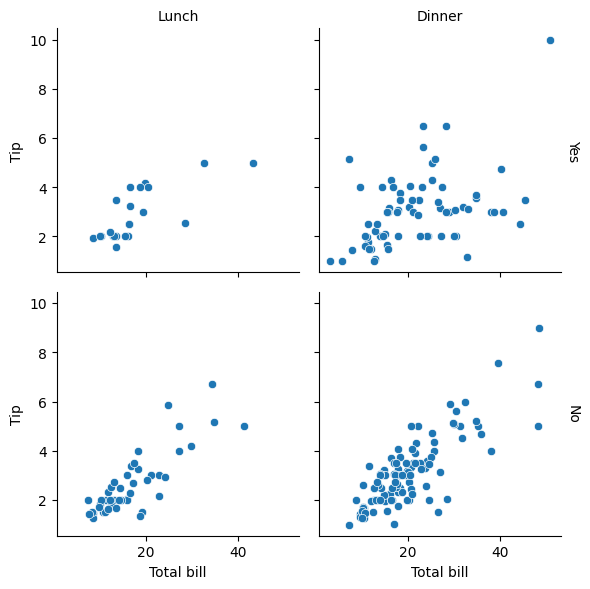

In [23]:
g = sns.FacetGrid(tips, col="time", row="smoker", margin_titles=True)
g.map_dataframe(sns.scatterplot, x="total_bill", y="tip")
g.set_axis_labels("Total bill", "Tip")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
plt.show()

### Exercise 6: FacetGrid for small multiples

Use `penguins`. Build a faceted figure comparing body-size measurements across
species and sex using `FacetGrid`.

1. Drop rows with missing `species`, `sex`, `flipper_length_mm`, or `body_mass_g`.
2. Create a `FacetGrid` with `col="species"`, `row="sex"`, `margin_titles=True`, and `height=4`.
3. Use `g.map_dataframe(sns.scatterplot, ...)` to plot `x="flipper_length_mm"` and `y="body_mass_g"`.
4. Add `hue="species"` to the scatterplot to encode species with color.
5. Use `g.set_axis_labels("Flipper length (mm)", "Body mass (g)")`.
6. Set figure-level titles using `g.set_titles(col_template="{col_name}", row_template="{row_name}")`.
7. Call `plt.tight_layout()` before displaying.
8. BONUS: Add `alpha=0.6` to the scatterplot to handle overplotting.
9. BONUS: Create a second version using `kind="violin"` instead of scatterplot and compare the clarity of each approach.
10. BONUS: Explore `g.set(ylim=(min_val, max_val))` to set consistent y-axis limits across all panels.